# Learnability filter on the AUC target (top 10)

Picks the few CTRPv2 drugs where a cross-cell-line signal can plausibly exist at all, so the
PCA-vs-scGPT question can be asked on drugs that are not hopeless by construction.

**Definition (June action item: "coverage >= threshold AND genuine response, not just std"):**

```
learnability = min(#killed, #spared)      killed: auc <= 0.5   spared: auc >= 0.8
gate:          coverage >= 90 % of the 180 labelled lines      -> top 10
```

A drug is only rankable across cell lines if it **separates** them: it must kill a real set of lines
*and* spare a real set. One that kills everything, or nothing, carries no cross-line signal however
good the model is.

**Why not the old score.** `drug_coverage` used `resp_std x coverage`. On `auc_z` that is degenerate (every drug
has std 1.0 by construction), and even on the raw `auc` scale it is the *weakest* label-only predictor
of the rho the model actually reaches (its top-10 gets rho 0.24, vs 0.33 for balanced separation).
Spread is not learnability: `fqi-2` has the 2nd-largest spread of all 545 drugs and kills **zero** lines.

Spread is measured on the **raw `auc` scale**, recoverable exactly from the targets file:

```
auc = auc_z * uns["ctrp_score_scale"] + uns["ctrp_score_center"]
```

> ⚠️ The filter sees **all 180 cell lines**, including val and test. The 10 drugs are therefore a
> **best-case subset** — this licenses a diagnosis, not a generalisation estimate. Train-only selection
> inside each CV fold is the open item.


In [1]:
import sys
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.preprocessing.layout import PipelinePaths

OUT = ROOT / 'notebooks' / 'outputs'; OUT.mkdir(parents=True, exist_ok=True)

SCORE, VARIANT = 'auc_z', 'hvg5000'
N_KEEP = 10                     # how many drugs to hand to training

paths = PipelinePaths.build(None, VARIANT, SCORE)
a = ad.read_h5ad(paths.targets_h5ad, backed='r')   # backed: .X stays on disk, we only touch obsm/uns
print(paths.targets_h5ad.name, '| score =', a.uns['ctrp_score'])

SCP542_CCLE_scGPT_human_embeddings_with_targets_auc_z.h5ad | score = auc_z


## 1. Collapse to the real (cell line × drug) measurements

The label is bulk: constant within a cell line, broadcast to all its cells. Anything per-drug must
therefore be computed on the **line-level** matrix, otherwise cell-rich lines get over-counted.

In [2]:
Y = np.asarray(a.obsm['Y_ctrp'], dtype=float)     # auc_z, NaN where unscreened
M = np.asarray(a.obsm['M_ctrp'], dtype=bool)
center = np.asarray(a.uns['ctrp_score_center'], dtype=float)   # per-drug mean of auc
scale = np.asarray(a.uns['ctrp_score_scale'], dtype=float)     # per-drug std  of auc
drugs = list(a.uns['ctrp_drugs'])
K = len(drugs)

lines = a.obs['Cell_line'].astype(str).to_numpy()
uniq = np.unique(lines)

# per-line value = mean over that line's observed cells (they are all identical anyway)
Z = np.full((len(uniq), K), np.nan)
for i, ln in enumerate(uniq):
    idx = np.flatnonzero(lines == ln)
    m = M[idx]
    has, cnt = m.any(0), m.sum(0)
    s = np.where(m, Y[idx], 0.0).sum(0)
    Z[i, has] = s[has] / cnt[has]

A = Z * scale + center                       # <- back to raw auc units
n_lines_tot = int(np.isfinite(Z).any(1).sum())

print(f'{len(uniq)} cell lines x {K} drugs; {n_lines_tot} lines carry >=1 label')
print(f'std of auc_z per drug : median {np.nanmedian(np.nanstd(Z, 0)):.4f}  <- degenerate by construction')
print(f'std of auc   per drug : median {np.median(scale):.4f}  (min {scale.min():.3f}, max {scale.max():.3f})')
print(f'auc overall: median {np.nanmedian(A):.3f}, p05 {np.nanpercentile(A, 5):.3f}, p95 {np.nanpercentile(A, 95):.3f}')

198 cell lines x 545 drugs; 180 lines carry >=1 label
std of auc_z per drug : median 1.0000  <- degenerate by construction
std of auc   per drug : median 0.1092  (min 0.034, max 0.302)
auc overall: median 0.877, p05 0.536, p95 1.071


## 2. Per-drug learnability

`auc` is viability-like, so on the raw scale:

- `n_sens` — lines the drug actually **kills** (`auc <= 0.5`)
- `n_res`  — lines that **survive** it (`auc >= 0.8`)

**`learnability = min(n_sens, n_res)`** — a drug scores only as high as its *weaker* side, so it must do
both. Coverage and spread are kept as descriptive columns; coverage is the only one still used as a gate.


In [3]:
SENS_MAX, RES_MIN = 0.5, 0.8      # auc thresholds: killed / survived

cov = np.isfinite(A).sum(0)
p05 = np.nanpercentile(A, 5, axis=0)
p95 = np.nanpercentile(A, 95, axis=0)

df = pd.DataFrame({
    'drug': drugs,
    'n_lines': cov,
    'cov_frac': cov / n_lines_tot,
    'auc_mean': np.nanmean(A, axis=0),
    'auc_std': scale,                          # == per-drug std of auc across lines
    'dyn_range': p95 - p05,
    'n_sens': (A <= SENS_MAX).sum(0),
    'n_res': (A >= RES_MIN).sum(0),
})

# balanced separation: a drug is only as learnable as its weaker side.
df['learnability'] = np.minimum(df['n_sens'], df['n_res'])

print(df[['auc_std', 'dyn_range', 'n_sens', 'n_res', 'learnability']]
      .describe().loc[['50%', '75%', 'max']].round(3).to_string())


     auc_std  dyn_range  n_sens  n_res  learnability
50%    0.109      0.306     0.0  108.0           0.0
75%    0.144      0.428     1.0  159.0           1.0
max    0.302      1.016   151.0  176.0          40.0


## 3. The gate and the selection

One gate, one score.

| | Value | Why |
|---|---|---|
| gate | `coverage >= 90 %` of the 180 lines | enough lines for the correlation to mean anything (n >= 162) |
| score | `min(n_sens, n_res)` | the drug must split the panel |
| keep | top 10 | |

**Coverage is deliberately not stricter than 90 %.** It is the weakest predictor of achieved rho (+0.16),
and the old 95 % gate rejected `ml210` — the single best drug in the panel (rho = 0.516) — at 0.94.


In [4]:
COV_MIN = 0.90

df['passes_gate'] = df['cov_frac'] >= COV_MIN
print(f'passing the coverage gate: {int(df["passes_gate"].sum())} / {K}')

df = df.sort_values(['passes_gate', 'learnability'], ascending=False).reset_index(drop=True)
df.insert(0, 'rank', df.index + 1)
df['selected'] = False
KEEP = df[df['passes_gate']].head(N_KEEP)['drug'].tolist()
df.loc[df['drug'].isin(KEEP), 'selected'] = True

print()
print(df[df['selected']][['rank', 'drug', 'n_lines', 'cov_frac', 'auc_std',
                          'n_sens', 'n_res', 'learnability']].round(3).to_string(index=False))


passing the coverage gate: 382 / 545

 rank         drug  n_lines  cov_frac  auc_std  n_sens  n_res  learnability
    1    daporinad      163     0.906    0.253      40     43            40
    2        ml210      170     0.944    0.193      39     56            39
    3    gsk461364      165     0.917    0.244      61     35            35
    4 oligomycin a      165     0.917    0.227      35     36            35
    5      kx2-391      175     0.972    0.179      34     33            33
    6 methotrexate      170     0.944    0.205      52     31            31
    7   rigosertib      172     0.956    0.157      29     33            29
    8     snx-2112      179     0.994    0.148      28     29            28
    9    dasatinib      177     0.983    0.155      35     27            27
   10        ml162      176     0.978    0.156      48     27            27


## 4. What the 5 look like vs. the other 540

Left: the `drug_coverage` coverage-vs-spread scatter, now on the auc scale, with the survivors marked — they sit
in the far top-right corner. Right: their response bands across cell lines. Unlike a typical CTRPv2
drug (whose lines are squeezed into a narrow high band), these actually **span** the panel from killed
to untouched, which is the only situation in which "rank the cell lines" is a well-posed task.

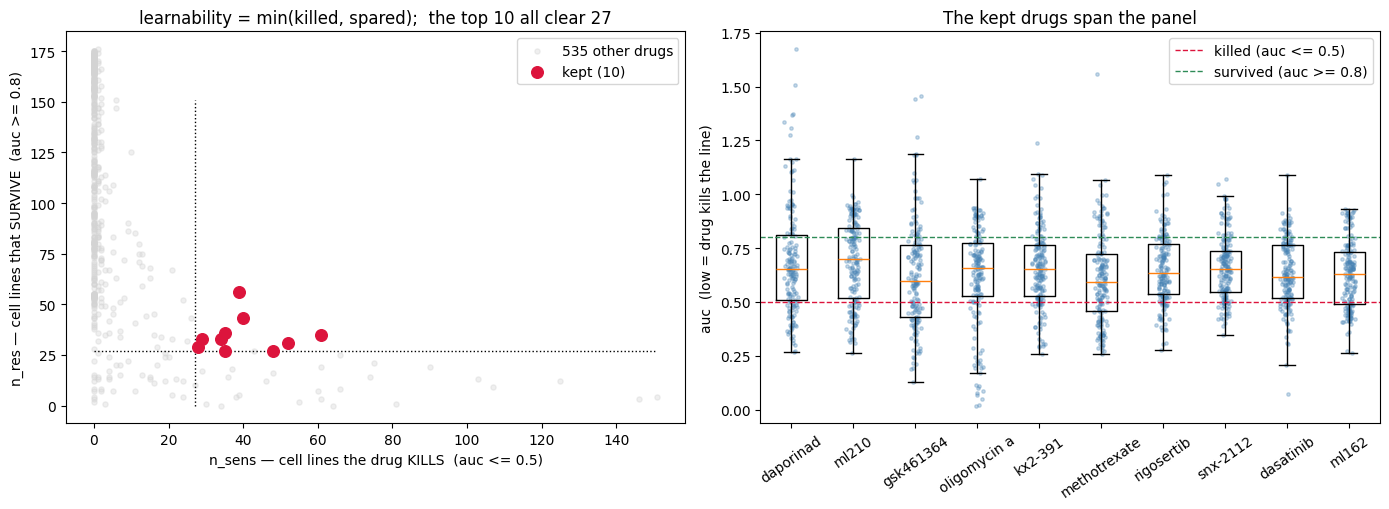

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))

sel = df['selected'].to_numpy()
ax[0].scatter(df.loc[~sel, 'n_sens'], df.loc[~sel, 'n_res'], s=14, alpha=0.35,
              color='lightgray', label=f'{int((~sel).sum())} other drugs')
ax[0].scatter(df.loc[sel, 'n_sens'], df.loc[sel, 'n_res'], s=70, color='crimson',
              zorder=3, label=f'kept ({int(sel.sum())})')
lo = int(df.loc[sel, 'learnability'].min())
xs = np.linspace(0, df['n_sens'].max(), 50)
ax[0].plot(xs, np.full_like(xs, lo), color='k', ls=':', lw=1)
ax[0].plot(np.full_like(xs, lo), xs, color='k', ls=':', lw=1)
ax[0].set_xlabel('n_sens — cell lines the drug KILLS  (auc <= 0.5)')
ax[0].set_ylabel('n_res — cell lines that SURVIVE  (auc >= 0.8)')
ax[0].set_title(f'learnability = min(killed, spared);  the top 10 all clear {lo}')
ax[0].legend(loc='upper right')

idx = [drugs.index(d) for d in KEEP]
data = [A[np.isfinite(A[:, k]), k] for k in idx]
ax[1].boxplot(data, vert=True, tick_labels=KEEP, showfliers=False)
for i, v in enumerate(data, start=1):
    ax[1].scatter(np.random.default_rng(42).normal(i, 0.05, len(v)), v, s=6, alpha=0.3, color='steelblue')
ax[1].axhline(SENS_MAX, color='crimson', ls='--', lw=1, label=f'killed (auc <= {SENS_MAX})')
ax[1].axhline(RES_MIN, color='seagreen', ls='--', lw=1, label=f'survived (auc >= {RES_MIN})')
ax[1].set_ylabel('auc  (low = drug kills the line)')
ax[1].set_title('The kept drugs span the panel')
ax[1].tick_params(axis='x', rotation=35)
ax[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'learnability' / 'learnability_filter_auc.png', dpi=200)
plt.show()


## 5. Save + the training command

The full 545-drug ranking goes to `outputs/archive/learnability/ctrp_drug_learnability_auc.csv` (the auc-scale counterpart
of `data/ctrp_drug_learnability.csv`, which was built on the legacy `mean_pv` target). The 5 kept drugs are
printed as a ready-to-paste `--drugs` argument.

In [6]:
full = df.round(5)
full.to_csv(OUT / 'learnability' / 'ctrp_drug_learnability_auc.csv', index=False)
print(f'saved {OUT / "learnability" / "ctrp_drug_learnability_auc.csv"}  ({len(full)} drugs, '
      f'{int(full["selected"].sum())} selected)')

drug_args = ' '.join(f'"{d}"' if ' ' in d else d for d in KEEP)
print('\nTrain PCA vs scGPT on the learnable subset:\n')
for rep in ('X_scGPT', 'X_pca'):
    print(f'  uv run scripts/training/train_multitask.py --variant {VARIANT} --score {SCORE} \\\n'
          f'      --use-rep {rep} --drugs {drug_args}\n')


saved outputs/learnability/ctrp_drug_learnability_auc.csv  (545 drugs, 10 selected)

Train PCA vs scGPT on the learnable subset:

  uv run scripts/training/train_multitask.py --variant hvg5000 --score auc_z \
      --use-rep X_scGPT --drugs daporinad ml210 gsk461364 "oligomycin a" kx2-391 methotrexate rigosertib snx-2112 dasatinib ml162

  uv run scripts/training/train_multitask.py --variant hvg5000 --score auc_z \
      --use-rep X_pca --drugs daporinad ml210 gsk461364 "oligomycin a" kx2-391 methotrexate rigosertib snx-2112 dasatinib ml162



## Read-out

**5 of 545 drugs survive** (6 pass the gates; the top 5 by `learnability = auc_std × cov_frac` are
kept). They are not a random sample — the list is dominated by compounds with a known
**differential** mechanism, which is a sanity check that the filter selects for biology rather than
noise:

- **1s,3r-RSL-3** and **ML162** — GPX4 inhibitors (ferroptosis). Sensitivity is known to track a
  cell's lipid-peroxidation / redox state, which is a *transcriptional* state — the best possible
  case for this project's hypothesis.
- **dasatinib** — SRC/ABL TKI, the textbook example of a drug that kills only the lines addicted to
  its target.
- **KX2-391** (SRC/tubulin) and **CAY10618** (NAMPT inhibitor) — likewise target-driven.

**Caveat, stated up front:** these gates were chosen *on the full panel*, val/test lines included, so
the 5 drugs are selected with knowledge of the held-out labels. That is acceptable for a
**best-case diagnostic** — the question being asked is "does *any* learnable signal exist here?", not
"what is the unbiased generalization error". If the answer turns out to be yes, the selection has to
be redone train-only before the number means anything.

Next: train PCA vs scGPT on exactly these 5 heads (command above) and check the per-drug Spearman
across held-out lines, which is the metric that mattered in `2_training` §3 — absolute MSE will hover near
1.0 by construction on a z-scored target.

## 4. How much do the thresholds matter?

`auc <= 0.5` (killed) and `auc >= 0.8` (spared) are **conventions, not derived quantities**. So the
question is not whether they are "right" but whether the result depends on them. Sweeping both:

| killed ≤ | spared ≥ | mean achieved ρ of the top-10 | overlap with the current 10 |
|---|---|---|---|
| 0.4 | 0.7 | 0.336 | 3 / 10 |
| 0.4 | 0.9 | 0.295 | 7 / 10 |
| **0.5** | **0.8** | **0.332** | **10 / 10** *(current)* |
| 0.5 | 0.7 | 0.340 | 5 / 10 |
| 0.6 | 0.8 | 0.276 | 4 / 10 |
| 0.7 | 0.8 | 0.273 | **0 / 10** |

**Two opposite readings, both true.**

- **The enrichment is robust.** Every threshold pair yields a top-10 with mean ρ between **0.27 and
  0.34**, against **0.12** for the panel as a whole. Requiring separation in *both* directions works,
  wherever you cut.
- **The selection is not.** At `0.7 / 0.8` the top-10 shares **zero** drugs with the current one — and
  reaches essentially the same quality. The ten names are an artifact of where the thresholds sit.

⇒ The filter is a usable **enrichment mechanism** and a poor **selection mechanism**. It cannot answer
*"which ten drugs"* — which is why the next step is a literature-driven selection, not a better threshold.
